# C14 · Small for gestational age: whose chart flags whom?

| | |
|---|---|
| **Difficulty** | ★★★★☆ |
| **Time** | 4-5 hours |
| **Data** | A random sample of 20,000 of the 3.49 million singleton births in the United States in 2023 (NCHS natality public-use file: birth weight, two gestational-age estimates, sex, smoking, gestational hypertension) |
| **Skills** | Unknown codes and competing measurements (two gestational-age estimates) · cleaning rules that must not touch the tail you care about · smooth quantile curves with a random-walk (discrete P-spline) prior · shrinking a sex difference where data are thin · the asymmetric Laplace as a working likelihood, and checking its bands against the bootstrap and on held-out births · a bootstrap-calibrated generalised (Gibbs) posterior · conditional vs population centile charts · turning two posteriors into "babies per 1000 flagged" with uncertainty, and a recommendation |

## The brief

A hospital network is replacing its newborn-assessment software. Every baby is weighed at birth,
and a baby lighter than the **10th centile of birth weight for its gestational age and sex** is
flagged **small for gestational age (SGA)**: it gets extra glucose checks, a paediatric review and
closer follow-up, because SGA babies carry a higher risk of stillbirth, hypoglycaemia and later
problems. The network's obstetric lead asks you:

> "Build us the 10th-centile chart, by sex, from recent US births - with an honest statement of how
> sure you are of it, especially for the preterm weeks. And a question our midwives keep asking:
> should babies of mothers who **smoked**, or who had **gestational hypertension**, be judged
> against their own charts? Those babies are smaller anyway. How many babies per 1000 would that
> stop - or start - flagging, and would you recommend it?"

This is the sequel to example **E83** (Bayesian quantile regression). Do E83 first: this challenge
assumes you know the check loss, why the asymmetric Laplace is only a *working* likelihood, and the
sandwich / learning-rate fixes. E83 asked what quantile regression can tell you; here a chart has
to be *used*, by sex, at every week from 24 to 42, and a policy question rides on it.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", q10_40_girls=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

from pymc_challenges import Hints, data

RANDOM_SEED = 2023
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 160)
T_START = time.time()

h = Hints("C14")
h.tasks()

**C14 - Small for gestational age: whose chart flags whom?**

- `task0` - Which gestational age? Which records? (3 hints, 1 check(s))
- `task1` - The quick chart (3 hints, 1 check(s))
- `task2` - A smooth chart that borrows strength (3 hints, 2 check(s))
- `task3` - Can you trust the bands? (3 hints, 2 check(s))
- `task4` - Charts for smokers and for gestational hypertension (3 hints, 2 check(s))
- `task5` - The decision (3 hints, 2 check(s))

## The data

One row per singleton birth. `load` only parses the raw NCHS codes; it does **not** clean them.

| column | meaning |
|---|---|
| `dbwt` | birth weight in grams (9999 = unknown) |
| `combgest` | gestation in completed weeks, **combined** estimate: from the date of the last menstrual period (LMP), with the obstetric estimate filled in when the LMP date is missing or implausible (99 = unknown) |
| `oegest_comb` | gestation in completed weeks, **obstetric estimate** recorded by the clinician (usually from an early ultrasound) (99 = unknown) |
| `sex` | M / F |
| `cig_0` ... `cig_3` | cigarettes per day before pregnancy and in trimesters 1, 2, 3 (99 = unknown) |
| `rf_ghype` | gestational hypertension: Y / N / U (unknown) |
| others | mother's age, race, education, BMI, weight gain, diabetes ... (see `data.describe`) |

In [2]:
data.describe("natality_births")
raw = data.load("natality_births")
raw[["dbwt", "combgest", "oegest_comb", "sex", "cig_1", "cig_2", "cig_3", "rf_ghype"]].describe(include="all").T

natality_births: A simple random sample of 20,000 of the 3,491,735 SINGLETON births of 2023 (raw codes; 9 / 99 / 99.9 / 999 / 9999 = unknown, empty = not reported): dob_mm, mager (mother's age), mrace6 (1 White, 2 Black, 3 AIAN, 4 Asian, 5 NHOPI, 6 more than one race), dmar (1 married, 2 unmarried; not reported for California), meduc (1-8 education, 9 unknown), tbo_rec (total birth order), previs (prenatal visits), cig_0..cig_3 (cigarettes per day before pregnancy and in trimesters 1-3), m_ht_in (inches), bmi (pre-pregnancy), pwgt_r (pre-pregnancy weight, lb), wtgain (lb), rf_pdiab / rf_gdiab / rf_ghype (pre-pregnancy diabetes, gestational diabetes, gestational hypertension: Y/N/U), sex (M/F), combgest and oegest_comb (gestation in weeks, combined and obstetric estimate), dbwt (birth weight, grams).
  source: National Center for Health Statistics (NCHS), National Vital Statistics System, Natality public use file 2023 (all 3,605,081 US birth certificates of 2023; codes as in the NCHS 'U

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dbwt,20000.0,NaN,NaN,NaN,3277.88435,593.076428,229.0,2976.0,3300.0,3629.0,9999.0
combgest,20000.0,NaN,NaN,NaN,38.66105,3.007759,17.0,38.0,39.0,40.0,99.0
oegest_comb,20000.0,NaN,NaN,NaN,38.4858,2.685286,17.0,38.0,39.0,39.0,99.0
sex,20000,2,M,10214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cig_1,20000.0,NaN,NaN,NaN,0.64555,5.98433,0.0,0.0,0.0,0.0,99.0
cig_2,20000.0,NaN,NaN,NaN,0.564,5.834981,0.0,0.0,0.0,0.0,99.0
cig_3,20000.0,NaN,NaN,NaN,0.92785,8.478664,0.0,0.0,0.0,0.0,99.0
rf_ghype,20000,3,N,17989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 0 · Which gestational age? Which records?

A chart is only as good as the gestational ages it is built on, and the file gives you two.

**Deliver**
1. The unknown codes that matter for a weight-for-age chart, and how many records they remove.
2. Evidence for choosing between `combgest` and `oegest_comb`: how often do they disagree, by how
   much, and what would each do to a weekly 10th centile - at the preterm weeks and after 41 weeks?
   Report the share of births with a known weight that `combgest` places at **43 weeks or more**.
3. A rule for records whose weight is implausible for their gestational age, and an argument for
   which side(s) of the distribution that rule may touch, given what the chart is for.
4. The range of weeks the chart can cover.

### Solution

Unknown codes first: 9999 g for weight and 99 weeks for gestation. A "99-week" baby would sit far
off the right of any curve; a 9999 g baby is heavier than any newborn ever recorded.

In [3]:
BLUE, ORANGE, AQUA, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0"
INK, MUTED, LIGHT = "#0b0b0b", "#8a8984", "#d9d8d3"

known = raw[(raw.dbwt < 9999) & (raw.combgest < 99) & (raw.oegest_comb < 99)].copy()
print(f"weight unknown: {int((raw.dbwt == 9999).sum())}; combgest unknown: {int((raw.combgest == 99).sum())}; "
      f"oegest_comb unknown: {int((raw.oegest_comb == 99).sum())}; records left: {len(known):,} of {len(raw):,}")
diff = known.combgest - known.oegest_comb
print(f"the two estimates agree exactly for {np.mean(diff == 0):.1%}; differ by 3+ weeks for {np.mean(diff.abs() >= 3):.1%}")
share_43 = np.mean(known.combgest >= 43)
print(f"combgest at 43+ weeks: {share_43:.2%} of births; oegest_comb at 43+ weeks: {np.mean(known.oegest_comb >= 43):.2%}")
print(pd.DataFrame({"combgest": known.combgest.value_counts(), "oegest_comb": known.oegest_comb.value_counts()})
      .fillna(0).astype(int).loc[lambda t: (t.index >= 40)].T.to_string())

weight unknown: 17; combgest unknown: 19; oegest_comb unknown: 19; records left: 19,970 of 20,000
the two estimates agree exactly for 66.1%; differ by 3+ weeks for 9.0%
combgest at 43+ weeks: 2.91% of births; oegest_comb at 43+ weeks: 0.02%
               40    41   42   43   44  45  46  47
combgest     3512  1443  461  259  168  73  49  33
oegest_comb  3520   966   51    0    1   1   1   0


In [4]:
assert h.check("task0", share_combgest_43plus=share_43)

- PASS `share_combgest_43plus` = 0.02914 is consistent with the reference solution.

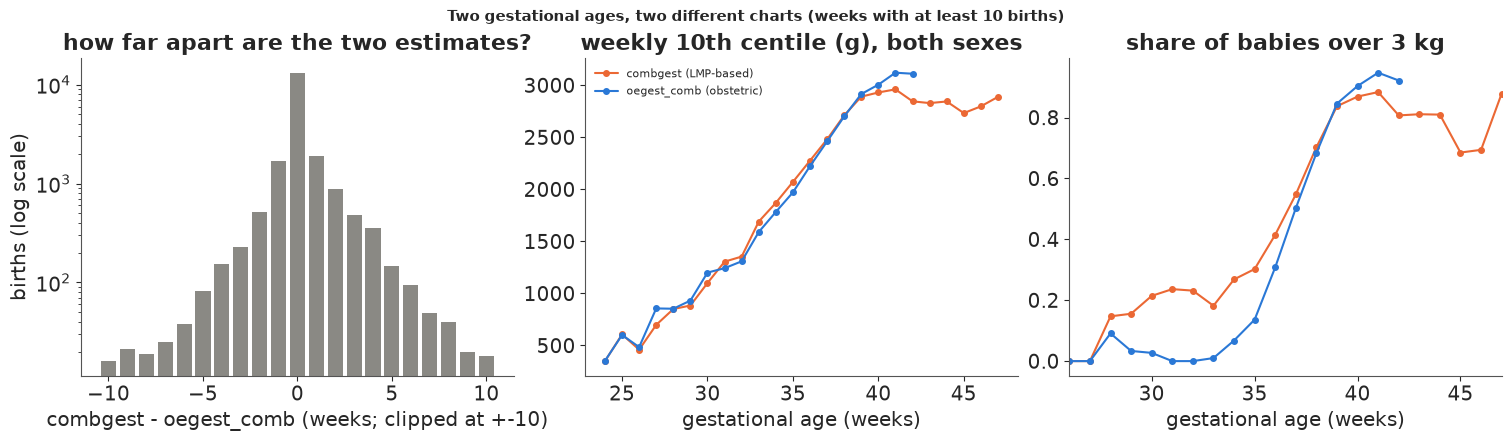

In [5]:
weeks_all = np.arange(24, 48)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
ax = axes[0]
vals, cnts = np.unique(diff.clip(-10, 10), return_counts=True)
ax.bar(vals, cnts, color=MUTED, width=0.8)
ax.set_yscale("log")
ax.set(xlabel="combgest - oegest_comb (weeks; clipped at +-10)", ylabel="births (log scale)",
       title="how far apart are the two estimates?")
for ax, stat, title in ((axes[1], lambda v: np.quantile(v, 0.1), "weekly 10th centile (g), both sexes"),
                        (axes[2], lambda v: np.mean(v > 3000), "share of babies over 3 kg")):
    for col, c, lab in (("combgest", ORANGE, "combgest (LMP-based)"), ("oegest_comb", BLUE, "oegest_comb (obstetric)")):
        vv = [stat(known.dbwt[known[col] == w]) if np.sum(known[col] == w) >= 10 else np.nan for w in weeks_all]
        ax.plot(weeks_all, vv, "o-", color=c, ms=4, label=lab)
    ax.set(xlabel="gestational age (weeks)", title=title)
axes[1].legend(fontsize=8)
axes[2].set_xlim(26, 47)
fig.suptitle("Two gestational ages, two different charts (weeks with at least 10 births)", fontsize=11);

The two estimates agree for about two births in three and differ by three weeks or more for about one
in eleven. The LMP-based `combgest` puts about 3% of births at **43-47 weeks**, which almost never
happens in modern obstetrics (labour is induced well before that); the obstetric estimate puts
three births there. The consequences for a chart:

* **After 41 weeks** the `combgest` 10th centile *falls* (middle panel): the "post-term" weeks are
  full of term babies whose LMP date was wrong. A chart built on them would be too lenient there.
* **Before 34 weeks** about one `combgest` baby in five weighs over 3 kg (right panel) - a term-sized
  baby dated as very preterm - against 0-3% from 29 to 33 weeks under the obstetric estimate (its 28-week
  point is two babies, both among the implausible records below).

The obstetric estimate is the better-dated measure, and it is the one NCHS itself has used as its
standard measure of gestational age since the 2014 data year. We use `oegest_comb` from here on.

**Implausible weight for age.** A few births are still impossible as recorded - a 3.4 kg baby at 28
weeks. The usual rule is symmetric (drop anything more than k robust standard deviations from the
weekly median). But the chart exists to find babies who are *too small for their age*. A 1.2 kg baby at
39 weeks is either misdated or severely growth-restricted, and it is exactly the second kind we must
not delete. So we trim the **upper** side only, and only where heavy outliers are biologically
implausible (preterm weeks): log weight more than 4 robust sds above the weekly, sex-specific median
before 37 weeks. That costs a handful of records and barely moves a 10th centile - the point is not to
touch the lower tail.

In [6]:
k_ = known[known.oegest_comb.between(24, 42)].copy()
lw = np.log(k_.dbwt)
grp = lw.groupby([k_.oegest_comb, k_.sex])
zrob = (lw - grp.transform("median")) / grp.transform(lambda v: 1.4826 * np.median(np.abs(v - np.median(v))))
print(f"more than 4 robust sds ABOVE the weekly median: {int((zrob > 4).sum())} (of them before 37 weeks: "
      f"{int(((zrob > 4) & (k_.oegest_comb < 37)).sum())}); BELOW: {int((zrob < -4).sum())}")
print(k_[(zrob > 4) & (k_.oegest_comb < 37)][["oegest_comb", "combgest", "dbwt", "sex"]].to_string(index=False))
print("some of the low ones a symmetric rule would delete:")
print(k_[zrob < -4][["oegest_comb", "combgest", "dbwt", "sex", "rf_ghype"]].head(8).to_string(index=False))
print(f"births before 24 weeks: {int((known.oegest_comb < 24).sum())}; after 42 weeks: {int((known.oegest_comb > 42).sum())}")

more than 4 robust sds ABOVE the weekly median: 14 (of them before 37 weeks: 5); BELOW: 22
 oegest_comb  combgest  dbwt sex
          30        33  2495   M
          26        27  2660   F
          28        38  3080   F
          28        28  3402   M
          27        41  2740   M
some of the low ones a symmetric rule would delete:
 oegest_comb  combgest  dbwt sex rf_ghype
          40        41  2200   F        N
          37        37  1724   M        N
          39        39  1185   F        Y
          38        40  1820   F        N
          34        36  1134   M        N
          38        39  1361   M        N
          38        33  1559   M        N
          36        27  1130   M        N
births before 24 weeks: 27; after 42 weeks: 3


The five preterm heavyweights (2.5-3.4 kg at 26-30 weeks) are far heavier than any plausible baby of their
recorded week; two of them have a combined estimate of 38 and 41 weeks - misdated. The low outliers include
babies of 1.2-1.8 kg at 37-39 weeks with *both* estimates agreeing on term - growth restriction, not a typo;
one mother had gestational hypertension.

**Range.** Below 24 weeks there are a few dozen births in 20,000, most of them before viability; above 42
weeks three. The chart covers **24-42 weeks** (obstetric estimate).

## The analysis data (everyone uses this from here on)

So that numbers can be compared, the rest of the notebook uses the rules above: obstetric gestational
age, 24-42 weeks, unknown weight / gestation / smoking (first or second trimester) / hypertension
dropped, and the upper-side-only, preterm-only trim. A **smoker** smoked in any trimester (a third-trimester
"unknown" counts as no information, not as a reason to drop: there was no third trimester for many
preterm babies, see E83). We model **log birth weight**: quantiles are equivariant under monotone
transforms, so the 10th centile of log weight is the log of the 10th centile, and effects become
percentages.

The births are split at random into a **training** set of 10,000 for fitting the chart and a
**held-out** set for checking it and for the decision.

In [7]:
ok = ((raw.dbwt < 9999) & (raw.oegest_comb < 99) & (raw.cig_1 < 99) & (raw.cig_2 < 99)
      & (raw.rf_ghype != "U") & raw.oegest_comb.between(24, 42))
births = raw[ok].copy()
births["lbw"] = np.log(births.dbwt / 1000)  # log kg
grp = births.groupby(["oegest_comb", "sex"]).lbw
zrob = (births.lbw - grp.transform("median")) / grp.transform(lambda v: 1.4826 * np.median(np.abs(v - np.median(v))))
births = births[~((zrob > 4) & (births.oegest_comb < 37))].reset_index(drop=True)
births["boy"] = (births.sex == "M").astype(int)
births["week"] = births.oegest_comb.astype(int)
births["smoker"] = ((births.cig_1 > 0) | (births.cig_2 > 0) | ((births.cig_3 > 0) & (births.cig_3 < 99))).astype(int)
births["hyp"] = (births.rf_ghype == "Y").astype(int)

WEEKS = np.arange(24, 43)
N_WEEKS = len(WEEKS)
SEXES = ["girl", "boy"]
N_TRAIN = 10_000
perm = rng.permutation(len(births))
train = births.iloc[perm[:N_TRAIN]].reset_index(drop=True)
test = births.iloc[perm[N_TRAIN:]].reset_index(drop=True)
y_tr, wk_tr, sx_tr = train.lbw.to_numpy(), train.week.to_numpy() - 24, train.boy.to_numpy()
y_te, wk_te, sx_te = test.lbw.to_numpy(), test.week.to_numpy() - 24, test.boy.to_numpy()
print(f"{len(births):,} births: training {len(train):,}, held out {len(test):,}; "
      f"smokers {births.smoker.mean():.1%}, gestational hypertension {births.hyp.mean():.1%}")
counts = pd.crosstab(train.sex, train.week)
counts

19,852 births: training 10,000, held out 9,852; smokers 3.2%, gestational hypertension 9.9%


week,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42
sex,,,,,,,,,,,,,,,,,,,
F,3,2,5,8,7,5,7,8,19,24,60,61,168,595,819,1918,906,256,11
M,4,6,6,4,3,10,11,8,21,26,61,91,190,619,950,1998,867,230,13


## Task 1 · The quick chart

The obvious chart: for each week and sex, the empirical 10th centile of the training births.

**Deliver**
1. The chart (both sexes, all weeks 24-42) on a scale where you can see the preterm weeks.
2. What is wrong with it, in words a neonatologist would accept: look at neighbouring weeks and at
   the difference between boys and girls where there are few births.
3. The share of **held-out** babies it flags, by gestational-age band and sex
   (24-31, 32-34, 35-36, 37, 38, 39, 40, 41-42 weeks). Is 10% what you get?

### Solution

In [8]:
emp = np.full((2, N_WEEKS), np.nan)
for s in range(2):
    for w in range(N_WEEKS):
        v = y_tr[(sx_tr == s) & (wk_tr == w)]
        if len(v):
            emp[s, w] = np.quantile(v, 0.1)
BANDS = [(24, 31), (32, 34), (35, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 42)]
BAND_LABELS = [f"{a}-{b}" if a != b else f"{a}" for a, b in BANDS]


def flag_table(q):
    """Held-out flag rate by band and sex for a chart q[sex, week] (log kg)."""
    flag = y_te < q[sx_te, wk_te]
    rows = []
    for (a, b), lab in zip(BANDS, BAND_LABELS):
        for s in range(2):
            m = (test.week.between(a, b)).to_numpy() & (sx_te == s)
            rows.append({"band": lab, "sex": SEXES[s], "n": int(m.sum()), "flagged": flag[m].mean()})
    return pd.DataFrame(rows)


tab1 = flag_table(emp)
print(tab1.pivot(index="band", columns="sex", values="flagged").loc[BAND_LABELS].round(3).T.to_string())
print(f"overall held-out flag rate: {np.mean(y_te < emp[sx_te, wk_te]):.3f}")
print("empirical 10th centiles (g):")
print(pd.DataFrame(np.exp(emp) * 1000, index=SEXES, columns=WEEKS).round(0).to_string())

band  24-31  32-34  35-36     37     38     39     40  41-42
sex                                                         
boy   0.157  0.179  0.092  0.094  0.090  0.091  0.123  0.127
girl  0.191  0.100  0.082  0.114  0.129  0.105  0.112  0.078
overall held-out flag rate: 0.105
empirical 10th centiles (g):
         24     25     26     27     28      29      30      31      32      33      34      35      36      37      38      39      40      41      42
girl  400.0  614.0  623.0  773.0  843.0   746.0  1149.0  1383.0  1472.0  1507.0  1782.0  1843.0  2153.0  2410.0  2660.0  2880.0  2978.0  3085.0  2920.0
boy   644.0  692.0  512.0  940.0  850.0  1055.0  1460.0  1234.0  1340.0  1733.0  1966.0  2110.0  2263.0  2510.0  2750.0  2955.0  3088.0  3188.0  3432.0


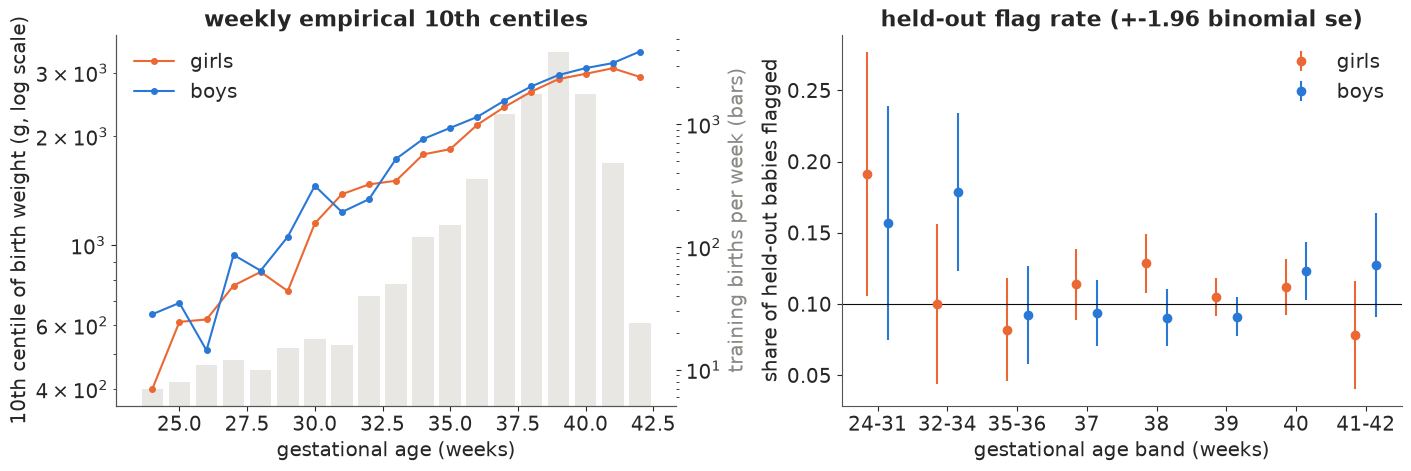

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
for s, c in ((0, ORANGE), (1, BLUE)):
    ax.plot(WEEKS, np.exp(emp[s]) * 1000, "o-", color=c, ms=4, label=SEXES[s] + "s")
ax.set_yscale("log")
ax.set(xlabel="gestational age (weeks)", ylabel="10th centile of birth weight (g, log scale)",
       title="weekly empirical 10th centiles")
ax.legend()
ax2 = ax.twinx()
ax2.bar(WEEKS, counts.sum(axis=0).reindex(WEEKS, fill_value=0), color=LIGHT, alpha=0.6, zorder=0)
ax2.set_yscale("log")
ax2.set_ylabel("training births per week (bars)", color=MUTED)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax = axes[1]
x_ = np.arange(len(BANDS))
for s, c, off in ((0, ORANGE, -0.15), (1, BLUE, 0.15)):
    t_ = tab1[tab1.sex == SEXES[s]]
    se = np.sqrt(0.09 / t_.n.to_numpy())
    ax.errorbar(x_ + off, t_.flagged, yerr=1.96 * se, fmt="o", color=c, label=SEXES[s] + "s")
ax.axhline(0.1, color=INK, lw=0.8)
ax.set(xticks=x_, xticklabels=BAND_LABELS, xlabel="gestational age band (weeks)", ylabel="share of held-out babies flagged",
       title="held-out flag rate (+-1.96 binomial se)")
ax.legend();

In [10]:
assert h.check("task1", q10_39_girls=np.exp(emp[0, WEEKS == 39][0]) * 1000)

- PASS `q10_39_girls` = 2880 is consistent with the reference solution.

From 36 to 41 weeks, with hundreds of births per week, the quick chart is fine: smooth, boys above girls by
2.5-5%, and the held-out flag rate is 8-13% at the term weeks. Before 34 weeks it is noise. With between 2
and 26 training births per week and sex, the "10th centile" is the first or second smallest baby: the curve
goes *down* from one week to the next several times (girls at 29 weeks, boys at 26, 28 and 31), and the gap
between boys and girls swings from boys 60% heavier (24 weeks) to girls heavier (26) and back to boys 27%
heavier (30) - no biology does that. On held-out babies three of the four preterm cells flag 16-19%; for two
of them (girls 24-31, boys 32-34) that is more than binomial noise explains. The chart needs to **borrow
strength**: across neighbouring weeks (growth is smooth) and between the sexes (the sex difference is small
and should change slowly).

## Task 2 · A smooth chart that borrows strength

Build a Bayesian model for the 10th centile of log birth weight at each week, for both sexes, that

* makes the curve smooth across weeks, with the amount of smoothing learned from the data;
* shares information between boys and girls: a common curve plus a sex difference that is small
  and changes slowly;
* uses the asymmetric Laplace working likelihood of E83 (`pm.AsymmetricLaplace(..., q=0.1)`).

**Deliver**
1. Your priors, and why the smoothing prior is on the scale you chose.
2. A fit with clean diagnostics.
3. The chart with 90% bands on top of Task 1's points, and the boy-girl difference by week.
4. The 10th centile at 40 weeks for girls and boys (posterior median, grams), and the held-out flag
   table of Task 1 for your new chart.

### Solution

Gestational age is recorded in whole weeks, so the "curve" is 19 numbers per sex and a smooth curve is
one whose **second differences** are small: a second-order random walk (RW2) on the weekly log 10th
centile, $f_{w+1} - 2f_w + f_{w-1} \sim N(0, s_f)$ - the discrete version of a P-spline penalty. Its scale
$s_f$ is learned. What is a plausible curvature? The weekly increase of log weight falls from about 0.15
(15% a week) around 30 weeks to about 0.03 at 41 weeks, so the slope changes by a few hundredths per
week: `HalfNormal(0.1)` on $s_f$ leaves room for that and pulls towards straighter curves where data are
thin. Each week's level gets a vague `Normal(0.5, 1)` (log kg: 1.6 kg give or take a factor of 2.7), so
the RW2 term does the smoothing.

The sexes: girls $= f - h/2$, boys $= f + h/2$, with the log ratio $h_w = h_0 + $ a first-order random
walk whose step sd is `HalfNormal(0.02)` (non-centred). Boys are typically a few percent heavier; that
prior says the difference drifts by a couple of percent across the whole range at most, unless the data
insist. One function builds the model for the rest of the notebook: with `w=None` it is the asymmetric
Laplace with a learned scale; with a number it becomes the generalised posterior of Task 3; `X` adds
covariates (Task 4).

In [11]:
D2 = np.diff(np.eye(N_WEEKS), 2, axis=0)  # second differences


def chart_model(y, wk, sx, tau=0.1, w=None, X=None):
    coords = {"week": WEEKS, "sex": SEXES}
    if X is not None:
        coords["cov"] = list(X.columns)
    with pm.Model(coords=coords) as m:
        f = pm.Normal("f", 0.5, 1.0, dims="week")                      # common log 10th centile
        s_f = pm.HalfNormal("s_f", 0.1)
        pm.Potential("rw2", pm.logp(pm.Normal.dist(0.0, s_f), pt.as_tensor(D2) @ f).sum())
        h0 = pm.Normal("h0", 0.0, 0.1)                                 # boy - girl, log scale
        s_h = pm.HalfNormal("s_h", 0.02)
        h_z = pm.Normal("h_z", 0.0, 1.0, dims="week")
        walk = pt.cumsum(h_z)
        h = pm.Deterministic("h", h0 + s_h * (walk - walk.mean()), dims="week")
        q = pm.Deterministic("q", pt.stack([f - h / 2, f + h / 2]), dims=("sex", "week"))
        mu = q[sx, wk]
        if X is not None:
            beta = pm.Normal("beta", 0.0, 0.2, dims="cov")
            mu = mu + pt.as_tensor(X.to_numpy(float)) @ beta
        if w is None:                                                  # asymmetric Laplace, learned scale
            sigma = pm.HalfNormal("sigma", 0.2)
            pm.AsymmetricLaplace("y", mu=mu, b=np.sqrt(tau * (1 - tau)) / sigma, q=tau, observed=y)
        else:                                                          # generalised posterior, rate w
            r = y - mu
            pm.Potential("loss", -w * (r * (tau - (r < 0))).sum())
    return m


def fit(model, label):
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95,
                          nuts={"adaptation": "low_rank"})
    names = [v for v in ("f", "h_z", "s_f", "s_h", "h0", "beta", "sigma") if v in idata.posterior]
    rh = max(float(az.rhat(idata, var_names=[v])[v].max()) for v in names)
    ess = min(float(az.ess(idata, var_names=[v])[v].min()) for v in names)
    print(f"{label}: {time.time() - t0:.0f} s; divergences {int(idata.sample_stats['diverging'].sum())}; "
          f"max r_hat {rh:.3f}; min bulk ESS {ess:.0f}; tuning steps {idata.posterior.attrs['tuning_steps']}")
    return idata


idata_ald = fit(chart_model(y_tr, wk_tr, sx_tr), "asymmetric Laplace chart")
print(az.summary(idata_ald, var_names=["s_f"], round_to=4).to_string())
print(az.summary(idata_ald, var_names=["s_h"], round_to=4).to_string())
print(az.summary(idata_ald, var_names=["sigma"], round_to=4).to_string())
q_ald = idata_ald.posterior["q"].to_numpy().reshape(-1, 2, N_WEEKS)
h_ald = idata_ald.posterior["h"].to_numpy().reshape(-1, N_WEEKS)

asymmetric Laplace chart: 26 s; divergences 0; max r_hat 1.009; min bulk ESS 388; tuning steps 800
       mean      sd  eti89_lb  eti89_ub  ess_bulk   ess_tail   r_hat  mcse_mean  mcse_sd
s_f  0.0242  0.0088    0.0141    0.0396  934.8781  1053.4954  1.0037     0.0003   0.0005
     mean      sd  eti89_lb  eti89_ub  ess_bulk  ess_tail   r_hat  mcse_mean  mcse_sd
s_h  0.02  0.0118    0.0061    0.0426  388.0751   610.958  1.0092     0.0006   0.0003
         mean      sd  eti89_lb  eti89_ub  ess_bulk   ess_tail   r_hat  mcse_mean  mcse_sd
sigma  0.0235  0.0002    0.0232    0.0239  4767.337  3080.0807  1.0015        0.0      0.0


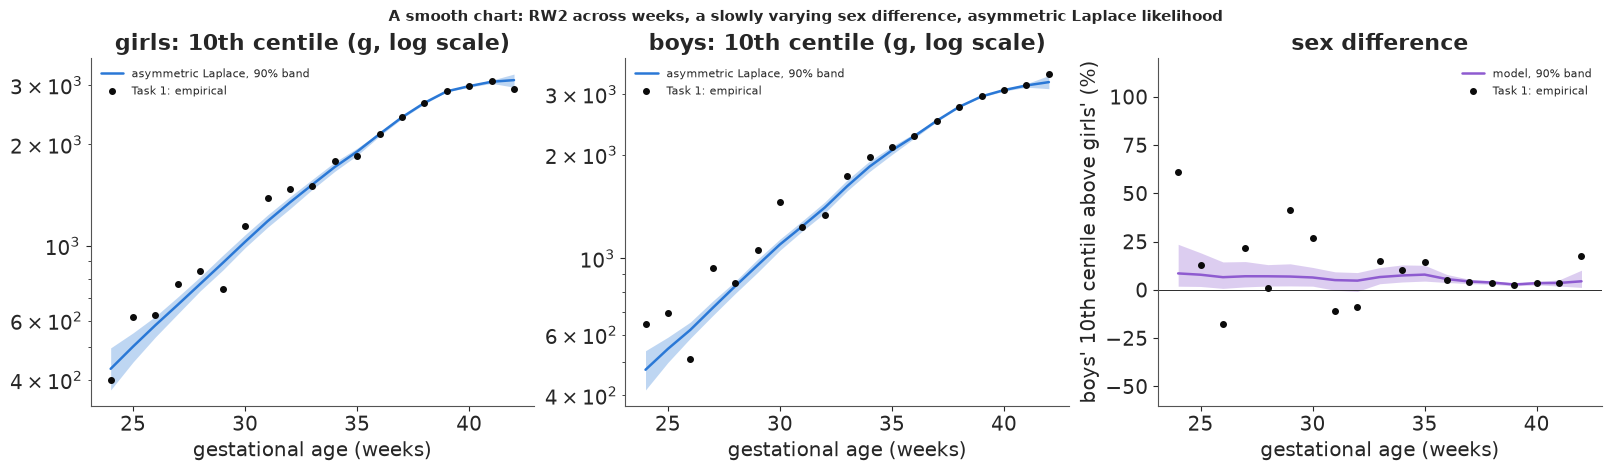

In [12]:
def plot_chart(ax, qd, color, label, s, band=0.9):
    lo, med, hi = np.quantile(np.exp(qd[:, s]) * 1000, [(1 - band) / 2, 0.5, (1 + band) / 2], axis=0)
    ax.fill_between(WEEKS, lo, hi, color=color, alpha=0.3, lw=0)
    ax.plot(WEEKS, med, color=color, lw=1.8, label=label)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for s, ax in enumerate(axes[:2]):
    plot_chart(ax, q_ald, BLUE, "asymmetric Laplace, 90% band", s)
    ax.plot(WEEKS, np.exp(emp[s]) * 1000, "o", color=INK, ms=4, label="Task 1: empirical")
    ax.set_yscale("log")
    ax.set(xlabel="gestational age (weeks)", title=f"{SEXES[s]}s: 10th centile (g, log scale)")
    ax.legend(fontsize=8)
ax = axes[2]
lo, med, hi = np.quantile(100 * (np.exp(h_ald) - 1), [0.05, 0.5, 0.95], axis=0)
ax.fill_between(WEEKS, lo, hi, color=PURPLE, alpha=0.3, lw=0)
ax.plot(WEEKS, med, color=PURPLE, lw=1.8, label="model, 90% band")
ax.plot(WEEKS, 100 * (np.exp(emp[1] - emp[0]) - 1), "o", color=INK, ms=4, label="Task 1: empirical")
ax.axhline(0, color=INK, lw=0.6)
ax.set(xlabel="gestational age (weeks)", ylabel="boys' 10th centile above girls' (%)", ylim=(-60, 120),
       title="sex difference")
ax.legend(fontsize=8)
fig.suptitle("A smooth chart: RW2 across weeks, a slowly varying sex difference, asymmetric Laplace likelihood", fontsize=11);

In [13]:
med_ald = np.median(q_ald, 0)
q40 = np.exp(med_ald[:, WEEKS == 40][:, 0]) * 1000
band40 = np.diff(np.quantile(np.exp(q_ald[:, :, WEEKS == 40][:, :, 0]) * 1000, [0.05, 0.95], axis=0), axis=0)[0]
print(f"10th centile at 40 weeks: girls {q40[0]:.0f} g, boys {q40[1]:.0f} g; width of the 90% band: "
      f"girls {band40[0]:.0f} g, boys {band40[1]:.0f} g")
print(pd.DataFrame(np.exp(med_ald) * 1000, index=SEXES, columns=WEEKS).round(0).to_string())
tab2 = flag_table(med_ald)
print(tab2.pivot(index="band", columns="sex", values="flagged").loc[BAND_LABELS].round(3).T.to_string())

10th centile at 40 weeks: girls 2979 g, boys 3084 g; width of the 90% band: girls 40 g, boys 39 g
         24     25     26     27     28     29      30      31      32      33      34      35      36      37      38      39      40      41      42
girl  432.0  503.0  582.0  669.0  771.0  889.0  1028.0  1183.0  1346.0  1520.0  1714.0  1905.0  2147.0  2408.0  2657.0  2875.0  2979.0  3070.0  3104.0
boy   475.0  546.0  620.0  718.0  830.0  955.0  1098.0  1240.0  1405.0  1621.0  1849.0  2061.0  2266.0  2512.0  2757.0  2957.0  3084.0  3181.0  3252.0
band  24-31  32-34  35-36     37     38     39     40  41-42
sex                                                         
boy   0.098  0.143  0.082  0.100  0.096  0.093  0.122  0.112
girl  0.149  0.082  0.090  0.114  0.129  0.105  0.112  0.082


In [14]:
assert h.check("task2", q10_40_girls=q40[0], q10_40_boys=q40[1])

- PASS `q10_40_girls` = 2979 is consistent with the reference solution.
- PASS `q10_40_boys` = 3084 is consistent with the reference solution.

The sampler is happy (no divergences, $\hat R \le 1.01$), the curves are smooth, and in the data-rich weeks
they sit on the empirical points. In the preterm weeks the model has pulled the jagged points onto a smooth,
increasing curve, and the sex difference is a slowly varying 3-9% instead of Task 1's swings (the model
also smooths away the boys' last point at 42 weeks, 13 births). The held-out flag rates in the preterm cells
are now 8-15% instead of 10-19%, though with 47-112 held-out babies per cell the binomial noise alone is 3-4.5
points (one sd).

The bands look reassuringly narrow - at 40 weeks about 40 g wide. Before anybody prints this chart,
Task 3 asks whether those bands mean what they say.

## Task 3 · Can you trust the bands?

The asymmetric Laplace is a working likelihood (E83). Find out what that does to *this* chart.

**Deliver**
1. At the data-rich weeks (37-41), compare the posterior sd of each sex's 10th centile with an honest
   frequentist yardstick. Report the median ratio (posterior sd / yardstick sd).
2. The held-out flag rates of Task 2 with an interval for each cell that includes **both** the
   binomial noise of the held-out cell and your posterior's uncertainty about the curve. How many cells
   fall outside their 90% interval? What can this check see, and what can it not?
3. Fix the bands - one of E83's fixes is enough - refit, and redo 1 and 2. Did anything besides the
   band width change? (Look at the learned smoothness.)

### Solution

**The yardstick.** At 37-41 weeks there are hundreds to thousands of training babies per week and sex, so
the smoothing prior hardly matters there and the posterior should be about as wide as the sampling
distribution of the plain weekly 10th centile. The **bootstrap** of the training births gives that.

In [15]:
TERM = np.flatnonzero((WEEKS >= 37) & (WEEKS <= 41))
N_BOOT = 300
rng_b = np.random.default_rng(RANDOM_SEED + 1)
boot = np.empty((N_BOOT, 2, len(TERM)))
for b in range(N_BOOT):
    i = rng_b.integers(0, N_TRAIN, N_TRAIN)
    yy, ww, ss = y_tr[i], wk_tr[i], sx_tr[i]
    for s in range(2):
        for j, w in enumerate(TERM):
            boot[b, s, j] = np.quantile(yy[(ss == s) & (ww == w)], 0.1)
sd_boot = boot.std(0)


def sd_ratio_table(qd):
    r = qd[:, :, TERM].std(0) / sd_boot
    return pd.DataFrame(r, index=SEXES, columns=WEEKS[TERM]), float(np.median(r))


rt_ald, ratio_ald = sd_ratio_table(q_ald)
print("posterior sd / bootstrap sd of the 10th centile, asymmetric Laplace:")
print(rt_ald.round(2).to_string())
print(f"median ratio {ratio_ald:.2f}; bootstrap sd in grams at 39 weeks (girls, boys): "
      f"{(sd_boot[:, list(WEEKS[TERM]).index(39)] * np.exp(med_ald[:, WEEKS == 39][:, 0]) * 1000).round(0)}")

posterior sd / bootstrap sd of the 10th centile, asymmetric Laplace:
        37    38    39    40    41
girl  0.39  0.53  0.69  0.51  0.69
boy   0.48  0.63  0.58  0.55  0.51
median ratio 0.54; bootstrap sd in grams at 39 weeks (girls, boys): [11. 16.]


The posterior is about **half as wide** as the bootstrap at the weeks where the bootstrap is reliable:
a nominal 90% band ($\pm 1.645$ posterior sds) is only about $\pm 0.9$ honest sds wide - roughly a 63% band. This is E83's sandwich result at work: the
asymmetric Laplace gets the curvature of the check loss right but not its variance.

**The held-out check.** For a cell with $n$ held-out babies, a chart that *is* the 10th centile flags a
Binomial$(n, 0.1)$ count. The chart's own uncertainty adds to that: evaluate every posterior draw of the
curve on the held-out babies of the cell and see how much its flag rate moves. The interval is
$0.1 \pm 1.645\sqrt{0.09/n + \operatorname{var}_{\text{draws}}(\text{rate})}$.

In [16]:
def heldout_check(qd, n_draws=1000):
    qd = qd[np.linspace(0, len(qd) - 1, n_draws).astype(int)]
    med = np.median(qd, 0)
    flag_draws = y_te[None] < qd[:, sx_te, wk_te]                       # draws x babies
    rows = []
    for (a, b), lab in zip(BANDS, BAND_LABELS):
        for s in range(2):
            m = test.week.between(a, b).to_numpy() & (sx_te == s)
            n = m.sum()
            sd_curve = flag_draws[:, m].mean(1).std()
            half = 1.645 * np.sqrt(0.09 / n + sd_curve ** 2)
            obs = np.mean(y_te[m] < med[sx_te[m], wk_te[m]])
            rows.append({"band": lab, "sex": SEXES[s], "n": n, "flagged": obs, "sd binomial": np.sqrt(0.09 / n),
                         "sd curve": sd_curve, "lo": 0.1 - half, "hi": 0.1 + half,
                         "inside": abs(obs - 0.1) <= half})
    return pd.DataFrame(rows)


chk_ald = heldout_check(q_ald)
print(chk_ald.round(3).to_string(index=False))
print(f"cells inside their 90% interval: {chk_ald.inside.sum()} of {len(chk_ald)}")

 band  sex    n  flagged  sd binomial  sd curve    lo    hi  inside
24-31 girl   47    0.149        0.044     0.016 0.024 0.176    True
24-31  boy   51    0.098        0.042     0.016 0.026 0.174    True
32-34 girl  110    0.082        0.029     0.016 0.046 0.154    True
32-34  boy  112    0.143        0.028     0.006 0.052 0.148    True
35-36 girl  268    0.090        0.018     0.004 0.069 0.131    True
35-36  boy  293    0.082        0.018     0.008 0.068 0.132    True
   37 girl  545    0.114        0.013     0.005 0.077 0.123    True
   37  boy  651    0.100        0.012     0.006 0.078 0.122    True
   38 girl  801    0.129        0.011     0.004 0.081 0.119   False
   38  boy  884    0.096        0.010     0.005 0.081 0.119    True
   39 girl 1922    0.105        0.007     0.004 0.087 0.113    True
   39  boy 1929    0.093        0.007     0.005 0.086 0.114    True
   40 girl  901    0.112        0.010     0.005 0.082 0.118    True
   40  boy  836    0.122        0.010     0.006 

Read the two sd columns. In every cell the binomial noise of the held-out babies is larger than the curve's
posterior uncertainty, usually two to three times larger: the held-out check is dominated by noise that has
nothing to do with the bands. It can catch a curve in the wrong *place* (a cell flagging 25% or 2%), but a
band half as wide as it should be hardly changes the intervals. With these overconfident bands 14 of 16 cells
are inside their 90% intervals - about what a correct model would give (14.4 expected). A held-out check is
only as sharp as the held-out sample is large; here the bootstrap, not the held-out set, exposes the bands.

**The fix.** A generalised (Gibbs) posterior, $\pi(\theta)\exp\{-w\sum_i\rho_{0.1}(y_i - \mu_i)\}$. The
asymmetric Laplace is the special case $w = 1/\sigma$. Posterior variance scales roughly like $1/w$, so we
calibrate $w = \frac{1}{\hat\sigma}\times$ (geometric mean over the 10 term cells of posterior variance /
bootstrap variance), and refit - E83's moment-matching recipe, applied where the bootstrap is reliable.

In [17]:
sigma_hat = float(idata_ald.posterior["sigma"].mean())
var_ratio = np.exp(np.mean(np.log((q_ald[:, :, TERM].std(0) / sd_boot) ** 2)))
w_cal = var_ratio / sigma_hat
print(f"asymmetric Laplace 1/sigma = {1 / sigma_hat:.1f}; calibrated learning rate w = {w_cal:.1f} "
      f"(the working likelihood learned {1 / var_ratio:.1f}x too fast)")
idata_cal = fit(chart_model(y_tr, wk_tr, sx_tr, w=w_cal), "calibrated generalised posterior")
q_cal = idata_cal.posterior["q"].to_numpy().reshape(-1, 2, N_WEEKS)
rt_cal, ratio_cal = sd_ratio_table(q_cal)
print(rt_cal.round(2).to_string())
print(f"median ratio {ratio_cal:.2f}")
for nm, idt in (("asymmetric Laplace", idata_ald), ("calibrated", idata_cal)):
    wd = np.diff(np.quantile(np.exp(idt.posterior["q"].to_numpy().reshape(-1, 2, N_WEEKS)) * 1000, [0.05, 0.95], axis=0), axis=0)[0]
    print(f"{nm:20s} 90% band width (g), girls / boys: 24 weeks {wd[:, 0].round(0)}, 30 weeks {wd[:, 6].round(0)}, "
          f"40 weeks {wd[:, 16].round(0)}")
    print(f"{nm:20s} smoothness s_f {float(idt.posterior['s_f'].mean()):.3f}, sex-difference step s_h "
          f"{float(idt.posterior['s_h'].mean()):.4f}")
chk_cal = heldout_check(q_cal)
print(f"held-out cells inside their 90% interval: {chk_cal.inside.sum()} of {len(chk_cal)}")
dmed = 100 * (np.exp(np.median(q_cal, 0) - med_ald) - 1)
print(f"calibrated minus asymmetric Laplace posterior-median chart: largest difference {np.abs(dmed).max():.1f}% "
      f"(at {SEXES[np.unravel_index(np.abs(dmed).argmax(), dmed.shape)[0]]}s, "
      f"{WEEKS[np.unravel_index(np.abs(dmed).argmax(), dmed.shape)[1]]} weeks); at 37-41 weeks at most {np.abs(dmed[:, TERM]).max():.1f}%")

asymmetric Laplace 1/sigma = 42.5; calibrated learning rate w = 12.8 (the working likelihood learned 3.3x too fast)


calibrated generalised posterior: 3 s; divergences 0; max r_hat 1.006; min bulk ESS 598; tuning steps 800
        37    38    39    40    41
girl  0.62  0.75  1.16  0.78  1.02
boy   0.84  0.97  0.89  0.87  0.73
median ratio 0.85
asymmetric Laplace   90% band width (g), girls / boys: 24 weeks [124. 124.], 30 weeks [91. 82.], 40 weeks [40. 39.]
asymmetric Laplace   smoothness s_f 0.024, sex-difference step s_h 0.0200
calibrated           90% band width (g), girls / boys: 24 weeks [154. 156.], 30 weeks [123. 125.], 40 weeks [62. 62.]
calibrated           smoothness s_f 0.024, sex-difference step s_h 0.0090
held-out cells inside their 90% interval: 15 of 16
calibrated minus asymmetric Laplace posterior-median chart: largest difference 4.2% (at girls, 24 weeks); at 37-41 weeks at most 0.2%


In [18]:
assert h.check("task3", sd_ratio_ald=ratio_ald, sd_ratio_fixed=ratio_cal)

- PASS `sd_ratio_ald` = 0.5363 is consistent with the reference solution.
- PASS `sd_ratio_fixed` = 0.8548 is consistent with the reference solution.

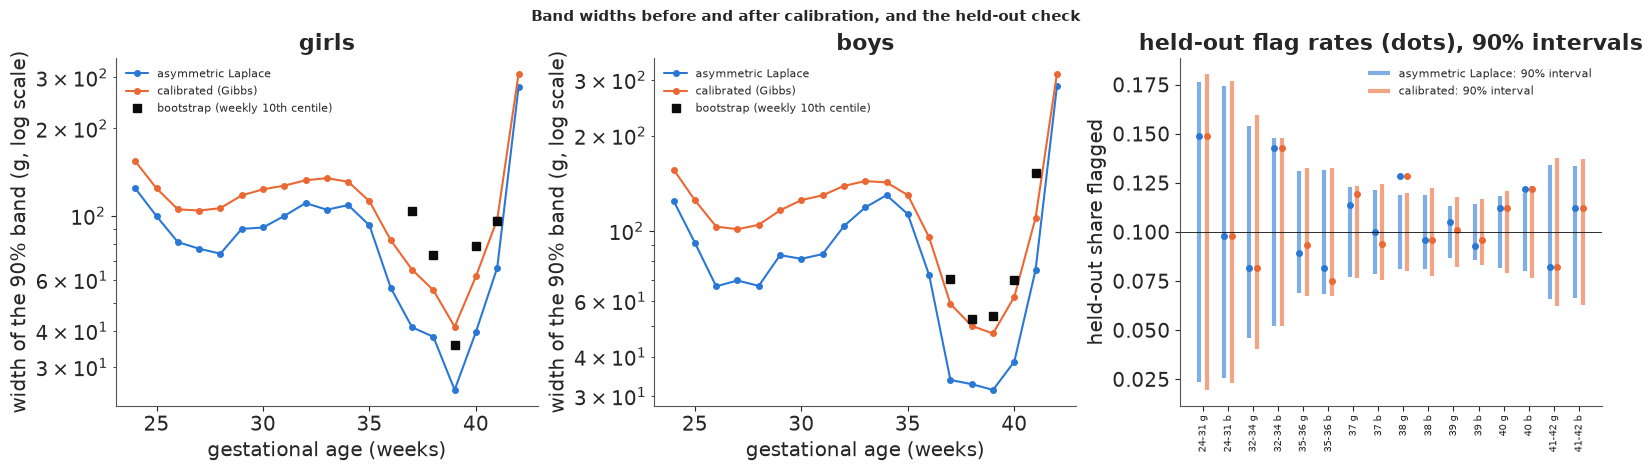

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for s, ax in enumerate(axes[:2]):
    for qd, c, nm in ((q_ald, BLUE, "asymmetric Laplace"), (q_cal, ORANGE, "calibrated (Gibbs)")):
        lo, hi = np.quantile(np.exp(qd[:, s]) * 1000, [0.05, 0.95], axis=0)
        ax.plot(WEEKS, hi - lo, "o-", color=c, ms=4, label=nm)
    med_g = np.exp(med_ald[s, TERM]) * 1000
    ax.plot(WEEKS[TERM], 2 * 1.645 * sd_boot[s] * med_g, "s", color=INK, ms=6, label="bootstrap (weekly 10th centile)")
    ax.set_yscale("log")
    ax.set(xlabel="gestational age (weeks)", ylabel="width of the 90% band (g, log scale)", title=f"{SEXES[s]}s")
    ax.legend(fontsize=8)
ax = axes[2]
x_ = np.arange(len(chk_ald))
for chk, c, off, nm in ((chk_ald, BLUE, -0.15, "asymmetric Laplace"), (chk_cal, ORANGE, 0.15, "calibrated")):
    ax.vlines(x_ + off, chk.lo, chk.hi, color=c, lw=3, alpha=0.6, label=f"{nm}: 90% interval")
    ax.plot(x_ + off, chk.flagged, "o", color=c, ms=4)
ax.axhline(0.1, color=INK, lw=0.6)
ax.set(xticks=x_, ylabel="held-out share flagged", title="held-out flag rates (dots), 90% intervals")
ax.set_xticklabels([f"{b} {s[0]}" for b, s in zip(chk_ald.band, chk_ald.sex)], rotation=90, fontsize=7)
ax.legend(fontsize=8)
fig.suptitle("Band widths before and after calibration, and the held-out check", fontsize=11);

The calibrated posterior is much closer to the bootstrap at term: median ratio 0.85 against 0.54, with
cells scattering from 0.6 to 1.2 (the bootstrap of a quantile is itself noisy). The remaining shortfall is
expected in part: the smooth model borrows from neighbouring weeks, which the weekly bootstrap does not, so
a ratio somewhat below 1 is honest. At 40 weeks the 90% band widened from about 40 g to about 60 g (left
panels; the black squares are the bootstrap's 90% widths). What else changed:

* **The curve hardly moved**: at 37-41 weeks the two posterior-median charts differ by at most 0.2%, in the
  preterm weeks by up to about 4% (girls, 24 weeks). The learned smoothness $s_f$ is the same (0.024) in both fits. The sex-difference step $s_h$ shrank from
  0.020 to 0.009: once the likelihood stops overstating the data, the wiggles of the preterm sex difference
  are no longer worth a rougher curve.
* **In the preterm weeks the bands widened less** (about 1.25x at 24 weeks, 1.35-1.5x at 30): there the band is
  set partly by the smoothing prior, which the learning rate does not touch. At 42 weeks (24 training births)
  both bands are about 300 g wide.
* **The held-out check passes before and after**, as predicted.

Two caveats for the obstetric lead. The calibration is done at term, where the bootstrap works; in the
preterm weeks one learning rate is an extrapolation, and the band there is as much the prior's as the
data's. And a 10th centile at 24-27 weeks estimated from about 20 training births per sex is not something
to print without a "few data" warning, whatever the model.

## Task 4 · Charts for smokers and for gestational hypertension

The midwives' question needs **conditional** 10th centiles: the 10th centile of birth weight given
week, sex, smoking and gestational hypertension.

**Deliver**
1. A model for that, built on Task 3's (calibrated) chart. Think about whether the hypertension
   effect should be the same before and after 37 weeks - and about *why* it might not be.
2. The effects at the 10th centile as percentages with 90% intervals, and a check that the intervals
   of the effect you will use in Task 5 are honest.
3. Explain why the hypertension effect at the 10th centile, *given gestational age*, is so much
   smaller than the roughly -290 g E83 found at the 10th centile without gestational age in the model.

### Solution

Add shifts on the log scale to Task 3's model: one for smoking, and for hypertension one for term births
and an extra one for preterm births. Hypertension is a reason to *deliver* early: severe pre-eclampsia,
often with a growth-restricted baby, ends in a preterm birth. Among preterm births, then, hypertension
selects the sickest pregnancies, and a single shift would average two different things. The learning rate
from Task 3 is a starting point; whether it also calibrates *these* coefficients is a question for the
bootstrap (E83: one scalar cannot fix every coefficient).

In [20]:
def covariates(df):
    return pd.DataFrame({"smoker": df.smoker, "hyp": df.hyp, "hyp_preterm": df.hyp * (df.week < 37)})


X_tr, X_te = covariates(train), covariates(test)
print(X_tr.sum().to_string())
idata_cond = fit(chart_model(y_tr, wk_tr, sx_tr, w=w_cal, X=X_tr), "conditional chart (calibrated rate)")
beta = idata_cond.posterior["beta"].to_numpy().reshape(-1, X_tr.shape[1])
q_cond = idata_cond.posterior["q"].to_numpy().reshape(-1, 2, N_WEEKS)


def rq_fn(X, y, tau, tol=1e-10, max_it=60):
    """Quantile regression by the Frisch-Newton interior-point method (from E83)."""
    n, p = X.shape
    A, c, u = X.T, -y, np.ones(n)
    x = (1 - tau) * u
    b = A @ x
    s = u - x
    yy = np.linalg.lstsq(A.T, c, rcond=None)[0]
    r = c - A.T @ yy
    r = r + 0.001 * (r == 0)
    z = np.where(r > 0, r, 0.0)
    w = z - r
    gap, scale = c @ x - yy @ b + w @ u, np.abs(c).sum() + 1.0
    step = lambda v, dv: np.where(dv < 0, -v / np.where(dv < 0, dv, -1), 1e20).min()  # noqa: E731
    for _ in range(max_it):
        if gap <= tol * scale:
            break
        q = 1 / (z / x + w / s)
        r = z - w
        AQ = A * np.sqrt(q)
        M = AQ @ AQ.T
        rhs = np.sqrt(q) * r
        dy = np.linalg.solve(M, AQ @ rhs)
        dx = q * (A.T @ dy - r)
        ds, dz, dw = -dx, -z * (dx / x + 1), -w * (-dx / s + 1)
        fp = min(0.9995 * min(step(x, dx), step(s, ds)), 1)
        fd = min(0.9995 * min(step(w, dw), step(z, dz)), 1)
        if min(fp, fd) < 1:
            mu = z @ x + w @ s
            g = (z + fd * dz) @ (x + fp * dx) + (w + fd * dw) @ (s + fp * ds)
            mu = mu * (g / mu) ** 3 / (2 * n)
            dxdz, dsdw = dx * dz, ds * dw
            xi = mu * (1 / x - 1 / s)
            rhs = rhs + np.sqrt(q) * (dxdz - dsdw - xi)
            dy = np.linalg.solve(M, AQ @ rhs)
            dx = q * (A.T @ dy + xi - r - dxdz + dsdw)
            ds = -dx
            dz = mu / x - z - z * dx / x - dxdz
            dw = mu / s - w - w * ds / s - dsdw
            fp = min(0.9995 * min(step(x, dx), step(s, ds)), 1)
            fd = min(0.9995 * min(step(w, dw), step(z, dz)), 1)
        x, s = x + fp * dx, s + fp * ds
        yy, w, z = yy + fd * dy, w + fd * dw, z + fd * dz
        gap = c @ x - yy @ b + w @ u
    return -yy


# classical reference: one dummy per (sex, week) cell plus the three shifts, bootstrapped. Weeks 32-42
# only: a dummy for a cell of two babies makes the linear programme degenerate (a singular Newton step).
ref = train.week.to_numpy() >= 32
cell = (sx_tr * N_WEEKS + wk_tr)[ref]
Xq = np.column_stack([np.eye(2 * N_WEEKS)[cell], X_tr.to_numpy(float)[ref]])
Xq, yq = Xq[:, Xq.sum(0) > 0], y_tr[ref]
b_lp = rq_fn(Xq, yq, 0.1)[-3:]
boot_b = np.empty((200, 3))
for b in range(200):
    i = rng_b.integers(0, len(yq), len(yq))
    boot_b[b] = rq_fn(Xq[i], yq[i], 0.1)[-3:]
summ4 = pd.DataFrame({"posterior mean (%)": 100 * (np.exp(beta.mean(0)) - 1),
                      "5%": 100 * (np.exp(np.quantile(beta, 0.05, axis=0)) - 1),
                      "95%": 100 * (np.exp(np.quantile(beta, 0.95, axis=0)) - 1),
                      "posterior sd (log)": beta.std(0), "LP estimate (%)": 100 * (np.exp(b_lp) - 1),
                      "bootstrap sd (log)": boot_b.std(0)}, index=X_tr.columns)
summ4["sd ratio"] = summ4["posterior sd (log)"] / summ4["bootstrap sd (log)"]
print(summ4.round(3).to_string())
hyp_pre_total = beta[:, 1] + beta[:, 2]
print(f"hypertension before 37 weeks (term + extra): {100 * (np.exp(hyp_pre_total.mean()) - 1):.1f}% "
      f"(90%: {100 * (np.exp(np.quantile(hyp_pre_total, 0.05)) - 1):.1f} to {100 * (np.exp(np.quantile(hyp_pre_total, 0.95)) - 1):.1f})")

smoker         324
hyp            993
hyp_preterm    171


conditional chart (calibrated rate): 6 s; divergences 0; max r_hat 1.006; min bulk ESS 574; tuning steps 800


             posterior mean (%)     5%    95%  posterior sd (log)  LP estimate (%)  bootstrap sd (log)  sd ratio
smoker                   -4.908 -6.962 -2.751               0.013           -5.329               0.012     1.081
hyp                      -0.656 -2.257  1.019               0.010           -0.542               0.010     0.998
hyp_preterm              -4.018 -8.139  0.015               0.026           -4.088               0.034     0.768
hypertension before 37 weeks (term + extra): -4.6% (90%: -8.5 to -0.9)


In [21]:
smoking_pct = 100 * (np.exp(beta[:, 0].mean()) - 1)
hyp_term_pct = 100 * (np.exp(beta[:, 1].mean()) - 1)
assert h.check("task4", smoking_pct=smoking_pct, hyp_term_pct=hyp_term_pct)

- PASS `smoking_pct` = -4.908 is consistent with the reference solution.
- PASS `hyp_term_pct` = -0.6559 is consistent with the reference solution.

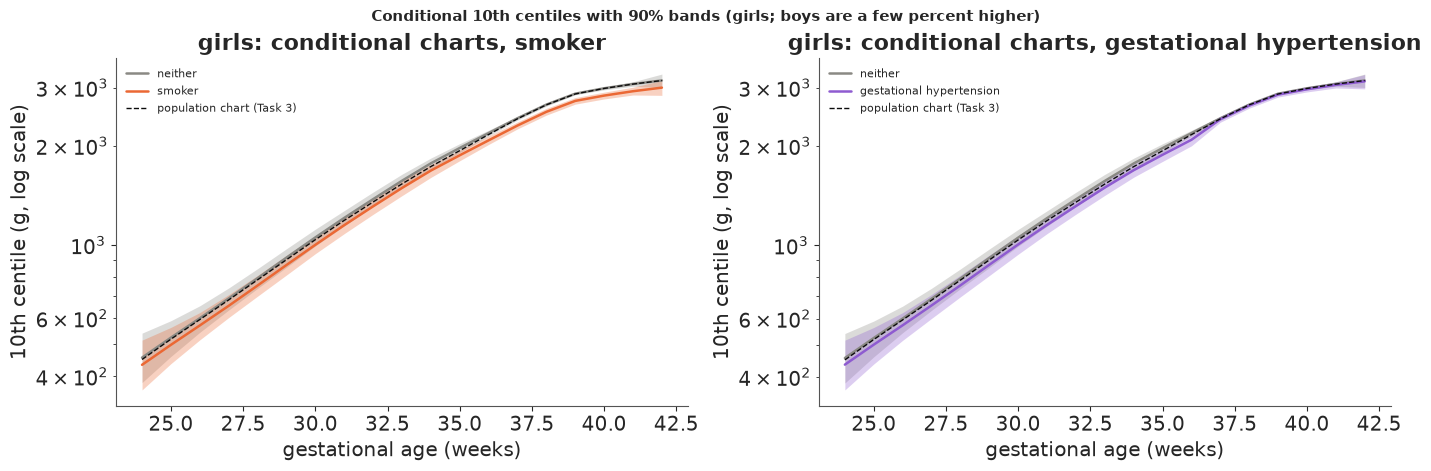

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
q_base = np.exp(q_cond[:, 0]) * 1000                                    # girls, neither exposure
for ax, (lab, shift, c) in zip(axes, (("smoker", beta[:, [0]], ORANGE),
                                      ("gestational hypertension", beta[:, [1]] + beta[:, [2]] * (WEEKS < 37), PURPLE))):
    for arr, cc, nm in ((q_base, MUTED, "neither"), (q_base * np.exp(shift), c, lab)):
        lo, med, hi = np.quantile(arr, [0.05, 0.5, 0.95], axis=0)
        ax.fill_between(WEEKS, lo, hi, color=cc, alpha=0.3, lw=0)
        ax.plot(WEEKS, med, color=cc, lw=1.8, label=nm)
    lo, med, hi = np.quantile(np.exp(q_cal[:, 0]) * 1000, [0.05, 0.5, 0.95], axis=0)
    ax.plot(WEEKS, med, color=INK, lw=1, ls="--", label="population chart (Task 3)")
    ax.set_yscale("log")
    ax.set(xlabel="gestational age (weeks)", ylabel="10th centile (g, log scale)", title=f"girls: conditional charts, {lab}")
    ax.legend(fontsize=8)
fig.suptitle("Conditional 10th centiles with 90% bands (girls; boys are a few percent higher)", fontsize=11);

Smoking lowers the 10th centile by about 5% at every week (about 150 g at term; 90% interval roughly -7% to
-3%). Before quoting intervals, read the **sd ratio** column: the learning rate calibrated on the weekly
curve gives the smoking and term-hypertension coefficients posterior sds within 10% of their bootstrap sds,
so their intervals can be used. The extra preterm hypertension shift is at 0.77 - somewhat overconfident -
and its bootstrap only sees 32-36 weeks (the linear programme cannot use the sparse earlier cells), so treat
that interval as a lower bound on the uncertainty.

Hypertension at term lowers the 10th centile by less than 1%, with an interval that includes zero; before
37 weeks the total shift is about -4.6% (-8.5% to -0.9%), from 171 hypertensive preterm births in training. The
contrast with E83's -290 g at the 10th centile is the **gestational age** in the model: most of what hypertension does to
birth weight it does by ending pregnancies early. Given the week, a hypertensive mother's baby at term is
barely lighter. For a weight-*for-age* chart, that is the relevant comparison.

## Task 5 · The decision

**Deliver**, on the held-out births, comparing the conditional chart (Task 4) with the population
chart (Task 3), with 90% intervals that include both charts' uncertainty and the sampling of the babies:
1. Per **1000 babies of smokers**, and per **1000 babies of hypertensive mothers**: how many fewer are
   flagged under the conditional chart?
2. Per **1000 births overall**: how many babies stop being flagged, how many *start* being flagged, and
   the net change. Explain the sign of each.
3. A recommendation to the obstetric lead in a few sentences - including a reason that does not come
   out of the posterior.

### Solution

For each posterior draw, flag every held-out baby under both charts. Draws from the two fits are paired
by index (they are independent fits, so this ignores their positive correlation and makes intervals of
*differences* a little conservative). To include the sampling of the babies - the hospital's future
patients are not these babies - each draw also gets Bayesian-bootstrap weights over the held-out births.

One trap: *which* babies switch cannot be counted by comparing two independent draws. Two draws of the
**same** chart disagree about babies sitting near the line, so draw-by-draw "stop" and "start" counts are
inflated by Monte Carlo jitter (their net is not). The network will deploy one chart of each kind - the
posterior medians - so the switches are counted between those, with the Bayesian bootstrap for the babies.

In [23]:
n_draws = 1000
idx_p = np.linspace(0, len(q_cal) - 1, n_draws).astype(int)
idx_c = np.linspace(0, len(q_cond) - 1, n_draws).astype(int)
Xte = X_te.to_numpy(float)
smk, hyp = X_te.smoker.to_numpy() == 1, X_te.hyp.to_numpy() == 1
rng_d = np.random.default_rng(RANDOM_SEED + 2)
res = {k: np.empty(n_draws) for k in ("smokers", "hypertension", "net", "pop_smk", "cond_smk", "jitter_off")}
for i, (sp, sc) in enumerate(zip(idx_p, idx_c)):
    wts = rng_d.dirichlet(np.ones(len(y_te)))
    f_pop = y_te < q_cal[sp][sx_te, wk_te]
    f_cond = y_te < q_cond[sc][sx_te, wk_te] + Xte @ beta[sc]
    d_ = f_cond.astype(float) - f_pop
    res["smokers"][i] = -1000 * np.sum(wts[smk] * d_[smk]) / wts[smk].sum()
    res["hypertension"][i] = -1000 * np.sum(wts[hyp] * d_[hyp]) / wts[hyp].sum()
    res["jitter_off"][i] = 1000 * np.sum(wts * (f_pop & ~f_cond))
    res["net"][i] = 1000 * np.sum(wts * d_)
    res["pop_smk"][i] = np.sum(wts[smk] * f_pop[smk]) / wts[smk].sum()
    res["cond_smk"][i] = np.sum(wts[smk] * f_cond[smk]) / wts[smk].sum()
# switches between the two deployed (posterior-median) charts
f_pop_d = y_te < np.median(q_cal, 0)[sx_te, wk_te]
f_cond_d = y_te < np.median(q_cond, 0)[sx_te, wk_te] + Xte @ np.median(beta, 0)
exposed = smk | hyp
for i in range(n_draws):
    wts = rng_d.dirichlet(np.ones(len(y_te)))
    for k, m in (("off", f_pop_d & ~f_cond_d), ("on", f_cond_d & ~f_pop_d),
                 ("off_exposed", f_pop_d & ~f_cond_d & exposed), ("on_unexposed", f_cond_d & ~f_pop_d & ~exposed)):
        res.setdefault(k, np.empty(n_draws))[i] = 1000 * np.sum(wts * m)
labels = {"smokers": "fewer flagged per 1000 babies of smokers", "hypertension": "fewer flagged per 1000 babies, hypertension",
          "net": "per 1000 births: net change in flagged", "off": "per 1000 births: stop being flagged",
          "off_exposed": "  of whom exposed (smoker or hypertension)", "on": "per 1000 births: start being flagged",
          "on_unexposed": "  of whom unexposed"}
print(pd.DataFrame({labels[k]: {"mean": res[k].mean(), "5%": np.quantile(res[k], 0.05), "95%": np.quantile(res[k], 0.95),
                                "P(> 0)": np.mean(res[k] > 0)} for k in labels}).T.round(2).to_string())
print(f"held-out: {smk.sum()} babies of smokers, {hyp.sum()} of hypertensive mothers, {len(y_te):,} in all")
print(f"babies of smokers flagged: population chart {res['pop_smk'].mean():.1%}, conditional chart {res['cond_smk'].mean():.1%}")
print(f"(comparing independent draws instead would count {res['jitter_off'].mean():.1f} per 1000 'stopping' - "
      f"vs {res['off'].mean():.1f} between the deployed charts)")

                                              mean     5%    95%  P(> 0)
fewer flagged per 1000 babies of smokers     62.04  32.39  96.25    1.00
fewer flagged per 1000 babies, hypertension  12.81 -10.78  37.04    0.80
per 1000 births: net change in flagged       -0.43  -8.09   7.11    0.46
per 1000 births: stop being flagged           2.75   1.97   3.69    1.00
  of whom exposed (smoker or hypertension)    2.75   1.97   3.69    1.00
per 1000 births: start being flagged          1.82   1.13   2.61    1.00
  of whom unexposed                           1.82   1.13   2.61    1.00
held-out: 307 babies of smokers, 980 of hypertensive mothers, 9,852 in all
babies of smokers flagged: population chart 16.2%, conditional chart 10.0%
(comparing independent draws instead would count 6.4 per 1000 'stopping' - vs 2.8 between the deployed charts)


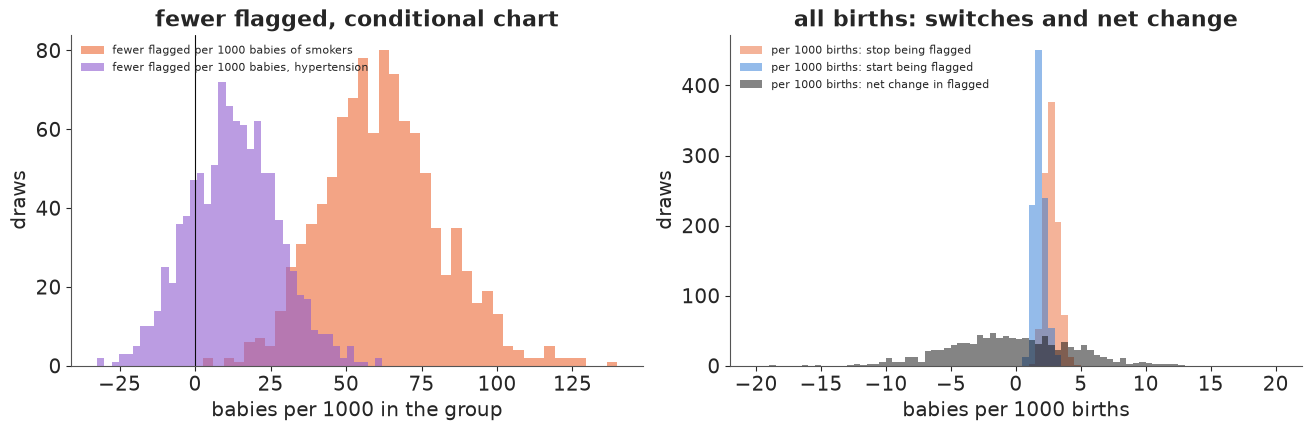

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
for k, c in (("smokers", ORANGE), ("hypertension", PURPLE)):
    ax.hist(res[k], bins=40, color=c, alpha=0.6, label=labels[k])
ax.axvline(0, color=INK, lw=0.8)
ax.set(xlabel="babies per 1000 in the group", ylabel="draws", title="fewer flagged, conditional chart")
ax.legend(fontsize=8)
ax = axes[1]
for k, c in (("off", ORANGE), ("on", BLUE), ("net", INK)):
    ax.hist(res[k], bins=np.arange(-20, 20.5, 0.5), color=c, alpha=0.5, label=labels[k])
ax.set(xlabel="babies per 1000 births", ylabel="draws",
       title="all births: switches and net change")
ax.legend(fontsize=8);

In [25]:
assert h.check("task5", fewer_per_1000_smokers=res["smokers"].mean(), net_per_1000_births=res["net"].mean())

- PASS `fewer_per_1000_smokers` = 62.04 is consistent with the reference solution.
- PASS `net_per_1000_births` = -0.4289 is consistent with the reference solution.

**What the numbers say.**

* Among babies of **smokers**, the population chart flags about one in six; a smoking-specific chart
  would flag one in ten - about **60 fewer per 1000** babies of smokers, with an interval that stays well
  away from zero.
* Among babies of **hypertensive mothers** the change is smaller and uncertain - about 13 per 1000, with an
  interval from about -11 to +37 - because, given the week, hypertension moves the 10th centile little except
  before 37 weeks.
* Over **all births** the net change is about **zero** (-0.4 per 1000, interval about -8 to +7): a
  conditional chart is a 10th centile too, so it flags about 10% of births overall. It does not flag fewer
  babies; it flags **different** babies. Between the two deployed charts, about 3 babies per 1000 births stop
  being flagged - all of them babies of exposed mothers - and about 2 per 1000 start, all babies of
  unexposed mothers, whose own 10th centile is a little *higher* than the population's. (Counting switches
  draw by draw would have reported 6 per 1000 stopping: jitter, not policy.)

**Recommendation.** Keep **one chart per sex** (the calibrated population chart of Task 3) and do not
introduce smoking- or hypertension-specific charts.

1. *The normative reason, which is not in the posterior.* A centile chart encodes what counts as
   normal growth. Smoking restricts fetal growth: babies of smokers are smaller *because* something is
   wrong, and that growth restriction carries the risks SGA flagging is meant to catch. A smoking chart
   would declare a smoking-restricted baby "normal for a smoker" and take it off the list - about 60
   babies per 1000 smokers. The same holds for hypertension, a disease of the placenta. Customised
   growth charts (Gardosi's GROW approach) adjust for *physiological* determinants of size (sex, maternal
   height, weight, parity, ethnic origin) and deliberately not for pathological ones such as smoking.
2. *The numbers do not make up for it.* The conditional chart does not reduce the workload (net change
   about zero); it moves surveillance from exposed babies to unexposed ones, which is the wrong direction.
3. *If the midwives' worry is over-flagging*, the honest answer is that among babies of smokers a higher
   flag rate is expected and appropriate. Smoking and hypertension belong in the risk assessment *alongside*
   the SGA flag, not inside the definition of normal.

**Caveats.** The chart is fitted on US births of 2023; the network should check its own flag rate by week
after a few months (Task 3's check, on their data). The preterm part rests on about 50 training births per
sex below 32 weeks; it is shown with its band and should carry a "few data" note.

In [26]:
print(f"total run time {time.time() - T_START:.0f} s")

total run time 42 s


## Going further

- **A 3rd centile ("severe SGA") line.** Fit it separately with the same model and check whether it
  crosses the 10th anywhere in the posterior draws; then fit both jointly with
  $\log q_{0.03} = \log q_{0.1} - e^{g}$ and a smooth $g$, which cannot cross. Does the 3rd centile need
  its own learning rate?
- **Does overconfidence roughen the curve?** Refit both charts on a few other random training sets. Does the
  asymmetric Laplace sometimes learn a larger $s_f$ (a rougher curve) than the calibrated posterior? Why would
  an overconfident likelihood push the smoothing prior towards more curvature?
- **Measurement error in the week.** Even the obstetric estimate is uncertain by about a week. Treat
  the true gestational age as latent (a mixture over neighbouring weeks) and see how much the preterm
  10th centiles move.
- **A mixture for the lower tail.** The 10th centile at 37 weeks is partly a statement about which
  babies are delivered early *because* they are small. Model birth weight at each week as a mixture of
  "normally grown" and "growth-restricted" components, and compare the flag it implies with the 10th
  centile.
- **Customised charts done right.** Add maternal height and parity (physiological), not smoking or
  hypertension (pathological), and redo Task 5. Which babies change status now?

In [27]:
h.progress()

**C14**: 0/18 hints used, 10/10 checks passed.